# Exploratory Data Analysis

## Setup

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tslearn.datasets import UCR_UEA_datasets

## Load data

In [2]:
# Load the LSST dataset from UEA archive
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

## Dataset properties

In [3]:
# tslearn loads data in the shape: (n_samples, n_timestamps, n_dimensions)
print("--- Dataset Shapes ---")
print(f"X_train shape: {X_train.shape} -> (Samples, Timesteps, Passbands)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

--- Dataset Shapes ---
X_train shape: (2459, 36, 6) -> (Samples, Timesteps, Passbands)
y_train shape: (2459,)
X_test shape:  (2466, 36, 6)
y_test shape:  (2466,)


In [4]:
# Confirmed: no NaN values in this UEA version of the dataset
num_nan_train = np.isnan(X_train).sum()
num_nan_test = np.isnan(X_test).sum()
print(f"NaN values in X_train: {num_nan_train}")
print(f"NaN values in X_test:  {num_nan_test}")

NaN values in X_train: 0
NaN values in X_test:  0


## Visualizing a Single Sample

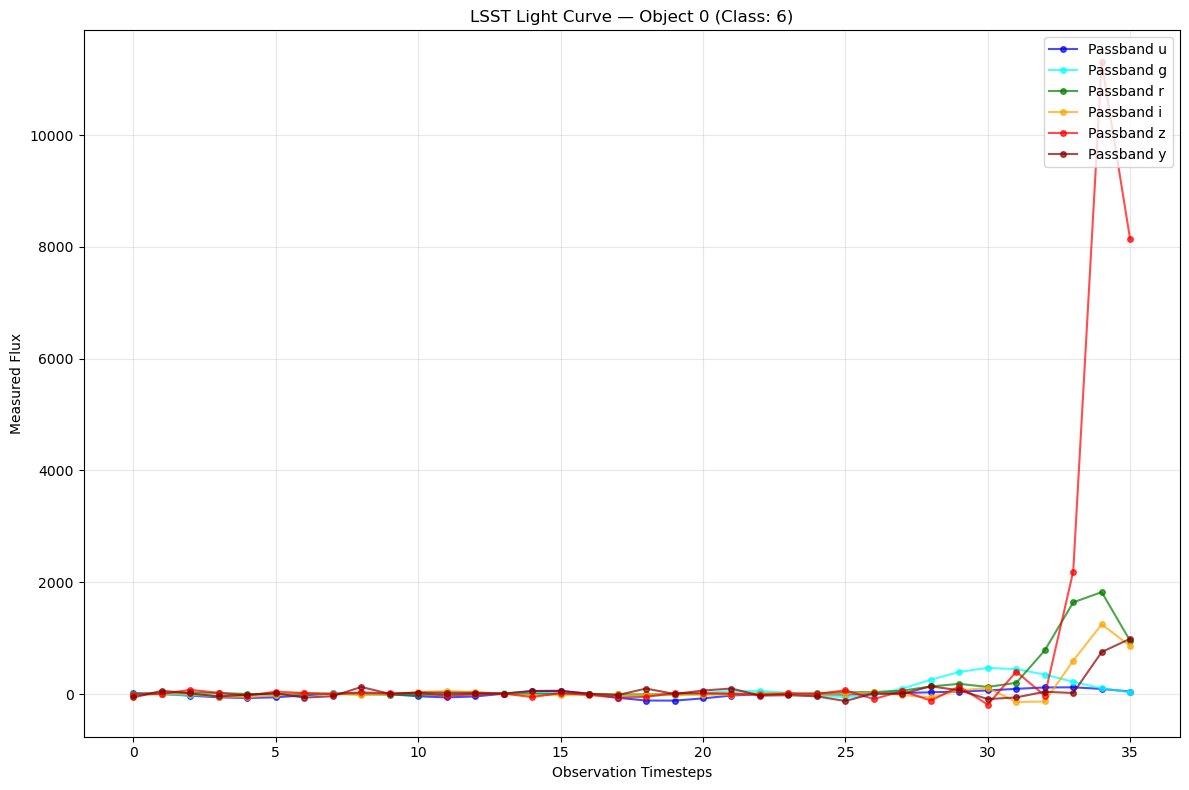

In [5]:
passbands = ['u', 'g', 'r', 'i', 'z', 'y']
colors = ['blue', 'cyan', 'green', 'orange', 'red', 'darkred']

sample_idx = 0
sample_ts = X_train[sample_idx]
sample_label = y_train[sample_idx]

plt.figure(figsize=(12, 8))
for i in range(sample_ts.shape[1]):
    plt.plot(sample_ts[:, i],
             label=f'Passband {passbands[i]}',
             color=colors[i],
             marker='o', markersize=4, linestyle='-', alpha=0.7)

plt.title(f"LSST Light Curve — Object {sample_idx} (Class: {sample_label})")
plt.xlabel("Observation Timesteps")
plt.ylabel("Measured Flux")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Class Distribution — Detailed

Number of classes: 14
Classes: ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']

Class       Train Count   Train %   Test Count    Test %
----------------------------------------------------------
15                  123      5.0%          124      5.0%
16                  270     11.0%          270     10.9%
42                  381     15.5%          382     15.5%
52                   62      2.5%           63      2.6%
53                    7      0.3%            7      0.3%
6                    34      1.4%           35      1.4%
62                  153      6.2%          153      6.2%
64                   23      0.9%           24      1.0%
65                  313     12.7%          313     12.7%
67                   68      2.8%           68      2.8%
88                  120      4.9%          121      4.9%
90                  777     31.6%          777     31.5%
92                   77      3.1%           77      3.1%
95                   51      2.1%       

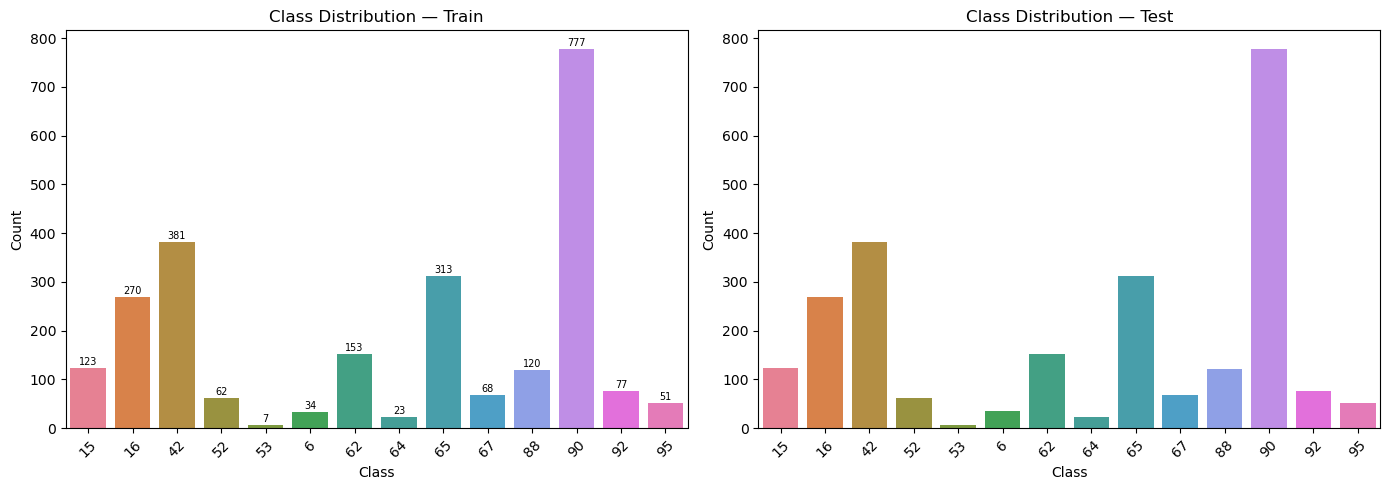

In [6]:
classes, counts = np.unique(y_train, return_counts=True)
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")
print()
print(f"{'Class':<10} {'Train Count':>12} {'Train %':>9} {'Test Count':>12} {'Test %':>9}")
print("-" * 58)
test_classes, test_counts = np.unique(y_test, return_counts=True)
test_count_map = dict(zip(test_classes, test_counts))
for cls, cnt in zip(classes, counts):
    tc = test_count_map.get(cls, 0)
    print(f"{cls:<10} {cnt:>12} {cnt/len(y_train)*100:>8.1f}% {tc:>12} {tc/len(y_test)*100:>8.1f}%")
print(f"{'TOTAL':<10} {len(y_train):>12} {'100%':>9} {len(y_test):>12} {'100%':>9}")
print()
print(f"Imbalance ratio (max/min count): {counts.max()/counts.min():.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab20", len(classes))

# Train
sns.barplot(x=[str(c) for c in classes], y=counts, hue=[str(c) for c in classes], ax=axes[0], legend=False)
axes[0].set_title("Class Distribution — Train")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
for ax_bar, val in zip(axes[0].patches, counts):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=7)

# Test
test_counts_ordered = [test_count_map.get(c, 0) for c in classes]
sns.barplot(x=[str(c) for c in classes], y=test_counts_ordered, hue=[str(c) for c in classes], ax=axes[1], legend=False)
axes[1].set_title("Class Distribution — Test")
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Per-class Light Curve Examples

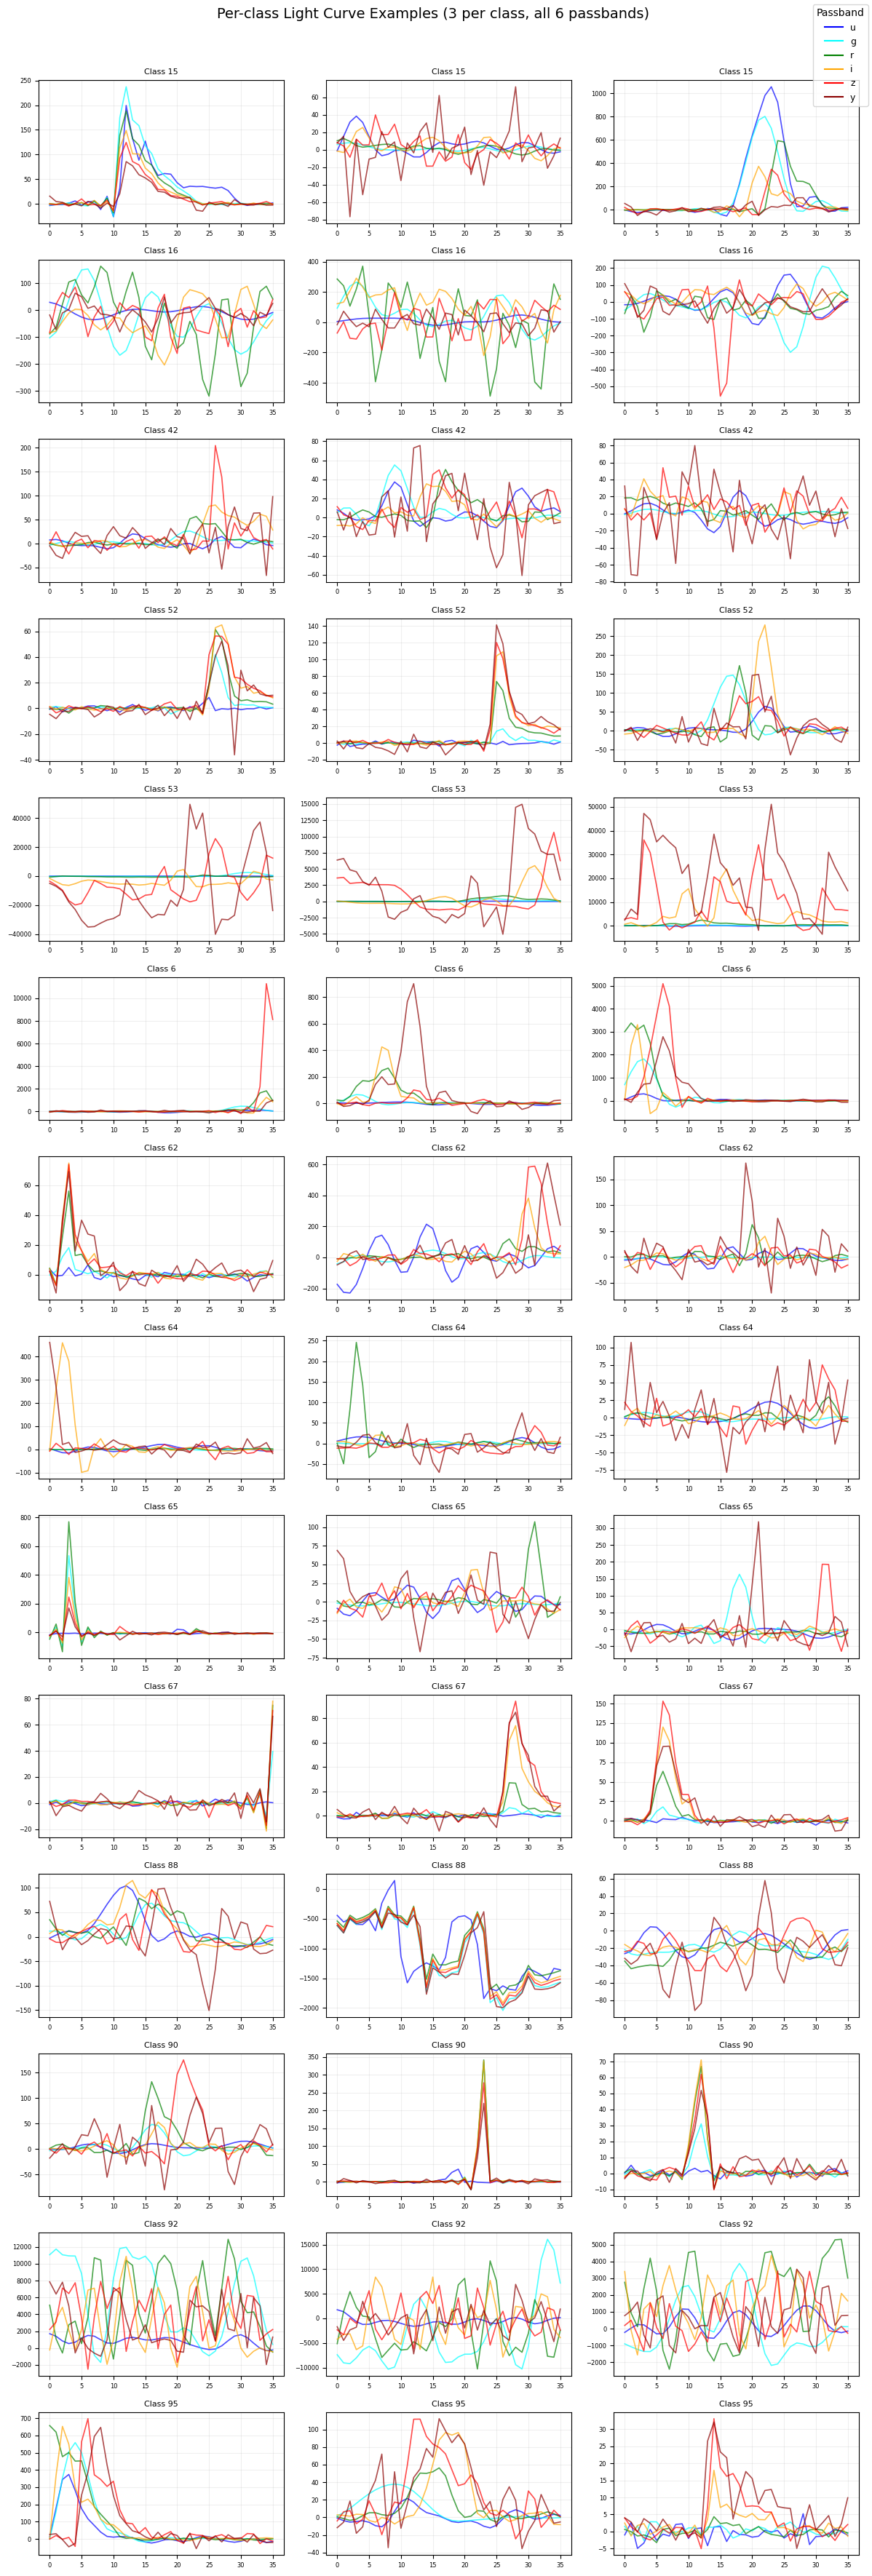

In [7]:
passbands = ['u', 'g', 'r', 'i', 'z', 'y']
colors = ['blue', 'cyan', 'green', 'orange', 'red', 'darkred']
classes_sorted = np.unique(y_train)
n_classes = len(classes_sorted)
n_examples = 3

fig, axes = plt.subplots(n_classes, n_examples, figsize=(n_examples * 4, n_classes * 2.5), squeeze=False)
fig.suptitle("Per-class Light Curve Examples (3 per class, all 6 passbands)", fontsize=14, y=1.01)

for row, cls in enumerate(classes_sorted):
    idx_cls = np.where(y_train == cls)[0]
    for col, si in enumerate(idx_cls[:n_examples]):
        ax = axes[row][col]
        for band_i in range(6):
            ax.plot(X_train[si, :, band_i], color=colors[band_i],
                    alpha=0.7, linewidth=1.2, label=passbands[band_i] if col == 0 else "")
        ax.set_title(f"Class {cls}", fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.2)

handles = [plt.Line2D([0], [0], color=colors[i], label=passbands[i]) for i in range(6)]
fig.legend(handles=handles, loc='upper right', title='Passband', fontsize=9)
plt.tight_layout()
plt.show()

## Data Structure & Per-passband Statistics

In [8]:
# All 36 timesteps are valid for every sample — no padding or missing data.
print(f"Dataset shape: {X_train.shape}  (samples, timesteps, passbands)")
print(f"Timesteps: {X_train.shape[1]} (fixed-length, uniformly pre-processed by UEA)")
print(f"Passbands: {X_train.shape[2]} — {passbands}")
print()
# Basic per-passband statistics
print(f"{'Passband':<10} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 52)
for i, pb in enumerate(passbands):
    vals = X_train[:, :, i]
    print(f"{pb:<10} {vals.min():>10.3f} {vals.max():>10.3f} {vals.mean():>10.3f} {vals.std():>10.3f}")

Dataset shape: (2459, 36, 6)  (samples, timesteps, passbands)
Timesteps: 36 (fixed-length, uniformly pre-processed by UEA)
Passbands: 6 — ['u', 'g', 'r', 'i', 'z', 'y']

Passband          Min        Max       Mean        Std
----------------------------------------------------
u           -3420.000  32932.000      9.457    248.782
g          -11585.000  44394.000     18.968    780.923
r          -10289.000  37032.000     28.008    714.907
i           -8009.900  48133.000     38.972    846.069
z          -19855.000  60249.000     50.137   1116.887
y          -40036.000  64062.000     55.648   1427.113


## Per-class Statistics per Passband

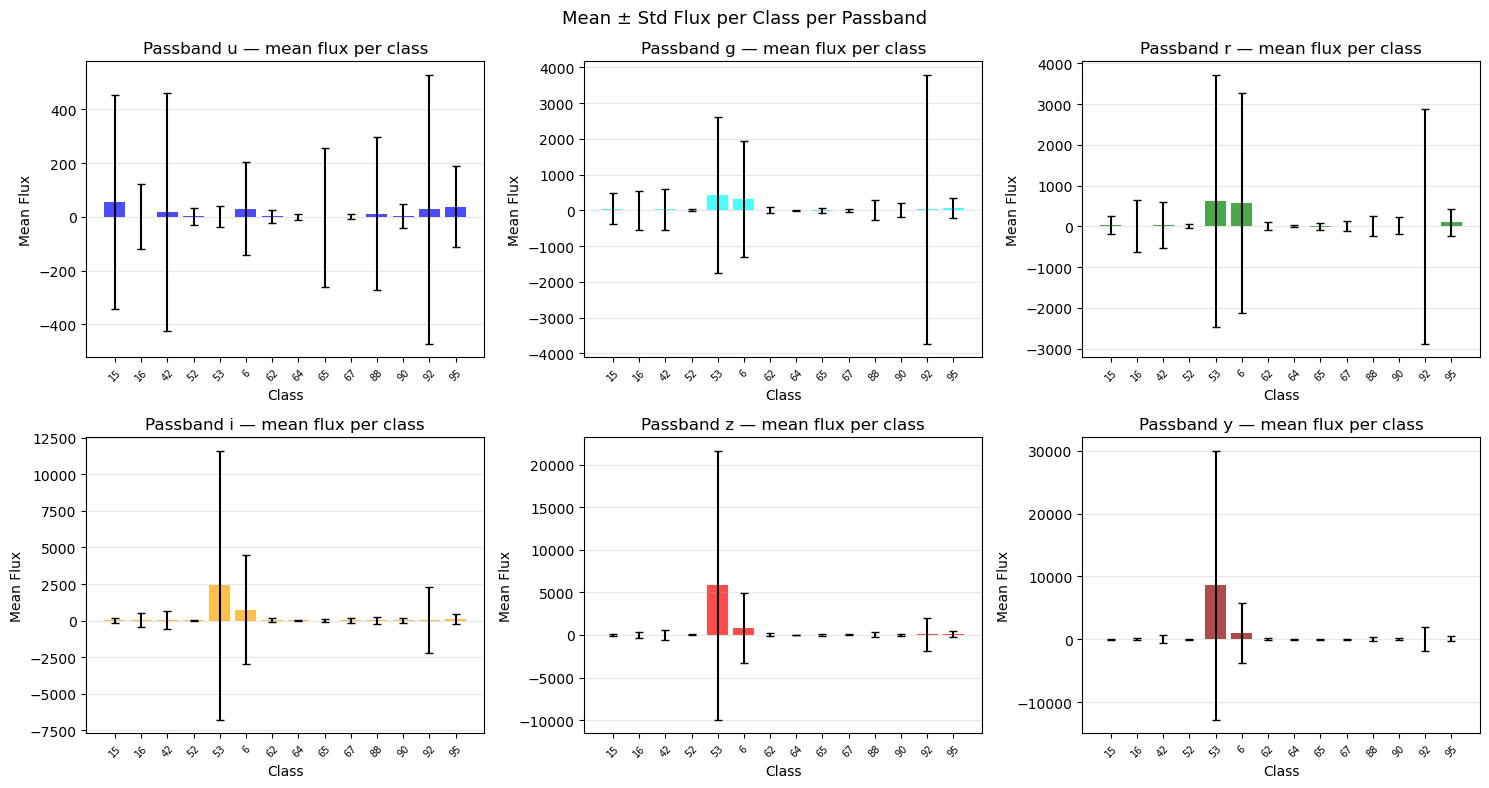

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for band_i, (ax, pb) in enumerate(zip(axes, passbands)):
    class_means = []
    class_stds = []
    for cls in classes_sorted:
        idx = np.where(y_train == cls)[0]
        band_vals = X_train[idx, :, band_i]
        class_means.append(band_vals.mean())
        class_stds.append(band_vals.std())

    x = np.arange(len(classes_sorted))
    ax.bar(x, class_means, yerr=class_stds, capsize=3, color=colors[band_i], alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(classes_sorted, fontsize=7, rotation=45)
    ax.set_title(f"Passband {pb} — mean flux per class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Flux")
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Mean ± Std Flux per Class per Passband", fontsize=13)
plt.tight_layout()
plt.show()

## Passband Correlations

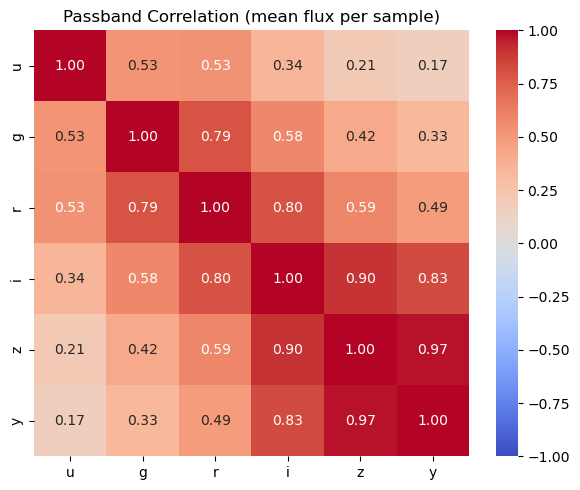

In [10]:
X_mean_per_band = X_train.mean(axis=1)  # (n_samples, 6): mean flux over time per passband
corr_matrix = np.corrcoef(X_mean_per_band.T)  # (6, 6)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, xticklabels=passbands, yticklabels=passbands, ax=ax)
ax.set_title("Passband Correlation (mean flux per sample)")
plt.tight_layout()
plt.show()

## Embedding Visualization (PCA → t-SNE / UMAP)

**Why flatten `36 × 6 = 216`?**  
PCA, t-SNE, and UMAP each expect one flat vector per sample. Our data is `(n, 36, 6)`, so we simply concatenate the 36 flux measurements of every passband end-to-end, giving a 216-dimensional vector. This preserves every raw observation — it is not a modelling choice, just a format conversion needed for these algorithms.

**Why PCA first (before t-SNE / UMAP)?**  
t-SNE and UMAP are expensive in high dimensions. Running them on 216 raw features would be slow and noisy (many dimensions carry redundant or near-zero variance). PCA first compresses to the top 50 directions that explain the most variance, discarding noise while keeping structure. t-SNE / UMAP then work on those 50 clean dimensions — faster *and* usually better quality embeddings. This PCA pre-processing step is a standard best practice.

PCA top-50 components explain 96.1% of variance
Components needed for 90% variance: 32


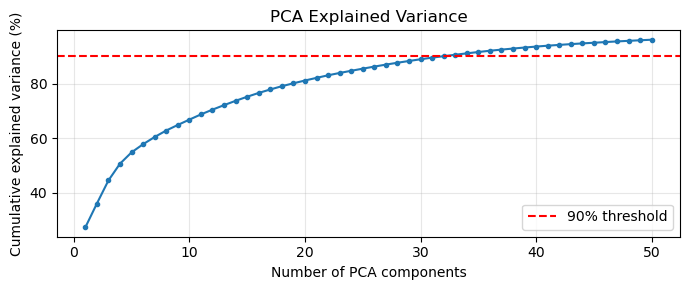

/sc/home/nemesio.navarro/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


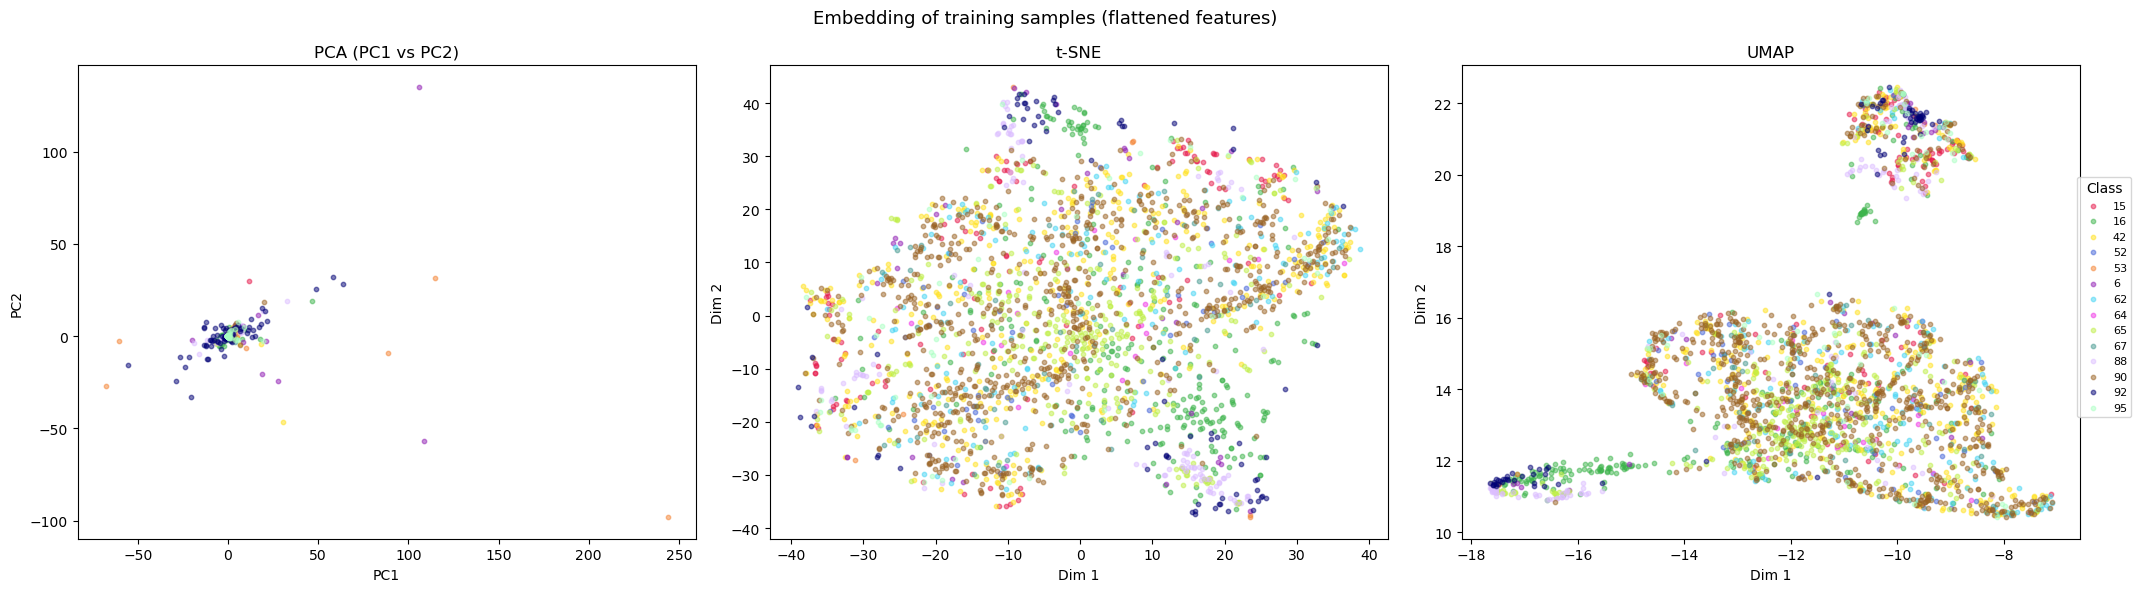

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

X_flat = X_train.reshape(X_train.shape[0], -1)  # (n_samples, 36*6=216)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cumvar = pca.explained_variance_ratio_.cumsum()
print(f"PCA top-50 components explain {cumvar[-1]*100:.1f}% of variance")
print(f"Components needed for 90% variance: {(cumvar < 0.90).sum() + 1}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, len(cumvar)+1), cumvar * 100, marker='.')
ax.axhline(90, color='red', linestyle='--', label='90% threshold')
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("PCA Explained Variance")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 14 hand-picked, perceptually distinct colours
palette = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#469990',
    '#dcbeff', '#9A6324', '#000075', '#aaffc3'
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for i, cls in enumerate(classes_sorted):
    mask = y_train == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[i], alpha=0.5, s=10, label=str(cls))
axes[0].set_title("PCA (PC1 vs PC2)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(X_pca)
for i, cls in enumerate(classes_sorted):
    mask = y_train == cls
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], color=palette[i], alpha=0.5, s=10, label=str(cls))
axes[1].set_title("t-SNE")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30)
X_umap = reducer.fit_transform(X_pca)
for i, cls in enumerate(classes_sorted):
    mask = y_train == cls
    axes[2].scatter(X_umap[mask, 0], X_umap[mask, 1], color=palette[i], alpha=0.5, s=10, label=str(cls))
axes[2].set_title("UMAP")
axes[2].set_xlabel("Dim 1"); axes[2].set_ylabel("Dim 2")

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, title="Class", loc='center right',
           bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.suptitle("Embedding of training samples (flattened features)", fontsize=13)
plt.tight_layout()
plt.show()

## Temporal Variability per Class per Passband

**What is the Coefficient of Variation (CoV)?**  
For a single light curve in a single passband we have 36 flux measurements across time. The CoV = std / |mean| summarises how "wiggly" that curve is relative to its average brightness: a flat curve gives CoV ≈ 0, while a highly pulsating or transient source gives a large CoV.

**Per-class, per-passband aggregation:**  
For every combination of (class, passband) we compute the CoV *for each sample individually* (over its 36 timesteps), then average those CoVs across all samples of that class. This tells us which classes are intrinsically more variable and whether variability differs across wavelength bands.

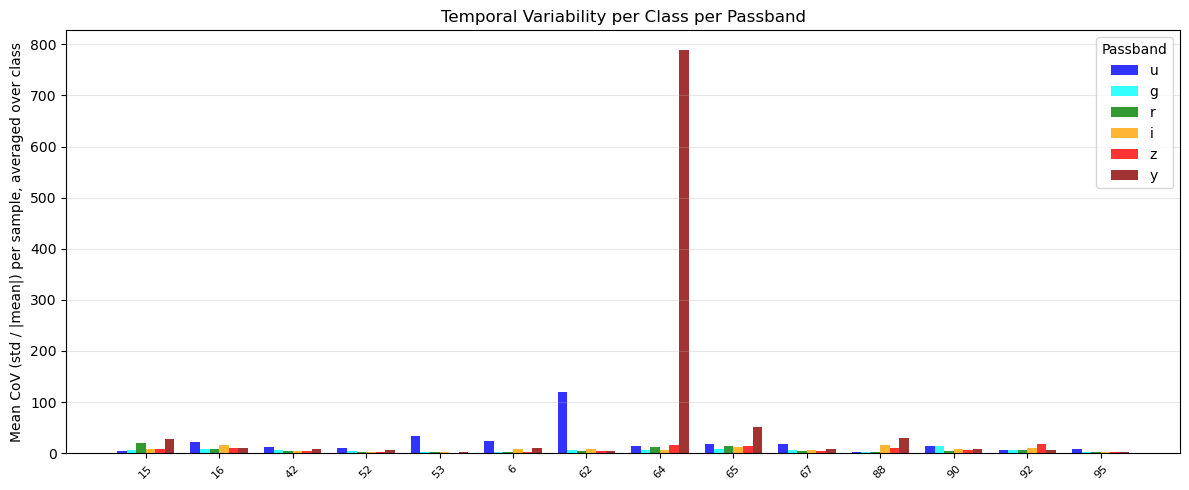

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(classes_sorted))
width = 0.13

for band_i, (pb, color) in enumerate(zip(passbands, colors)):
    cvs = []
    for cls in classes_sorted:
        idx = np.where(y_train == cls)[0]
        band_vals = X_train[idx, :, band_i]  # (n_cls, 36)
        # CoV per sample: std over 36 timesteps / |mean over 36 timesteps|
        sample_cov = band_vals.std(axis=1) / (np.abs(band_vals.mean(axis=1)) + 1e-8)
        cvs.append(sample_cov.mean())          # average CoV for this class
    ax.bar(x + band_i * width, cvs, width, label=pb, color=color, alpha=0.8)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(classes_sorted, rotation=45, fontsize=8)
ax.set_ylabel("Mean CoV (std / |mean|) per sample, averaged over class")
ax.set_title("Temporal Variability per Class per Passband")
ax.legend(title="Passband", loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## EDA Summary

### Dataset
- Shape `(2459, 36, 6)` train / `(2466, 36, 6)` test — 36 uniformly-spaced timesteps, 6 passbands, no missing values.
- Mean flux increases monotonically with wavelength: u≈9 → g≈19 → r≈28 → i≈39 → z≈50 → y≈56, reflecting the spectral energy distribution of the sources.

### Class Imbalance
- **Severe imbalance: 111× ratio** (class 90: 777 samples = 31.6% vs. class 53: 7 samples = 0.3%).
- Train and test distributions are essentially identical, so test performance should reflect real imbalance.
- **→ Weighted cross-entropy loss (or oversampling of minority classes) is mandatory.**

### Passband Correlations
- The IR bands are tightly coupled: z–y = 0.97, i–z = 0.90, r–i = 0.80. The g–r pair is also strong (0.79).
- **u is the most independent band** (correlations 0.17–0.53 with all others), carrying unique UV information.
- Models that treat channels independently (channel-independence mode) will miss meaningful inter-band structure. Prefer models that can handle **multivariate** input natively.

### Embedding Separability (PCA / t-SNE / UMAP)
- **PCA:** Almost all samples collapse into one dense blob; a few outliers (likely classes 62/64) are well separated but the rest are not.
- **t-SNE:** Classes are heavily intermixed — raw flattened features provide very poor linear separability. A frozen embedding + linear head is unlikely to be sufficient.
- **UMAP:** Reveals partial structure — one distinct isolated cluster (top-right) and an elongated manifold — but most classes still overlap significantly.
- **→ Full fine-tuning of the foundation model is needed; frozen embeddings will not be enough.**

### Temporal Variability (CoV)
- Most classes have low-to-moderate variability (CoV < 30 in all bands).
- **Classes 64 and 62 are strong outliers**: CoV ≈ 790 (class 64, y-band) and ≈ 120 (class 62, u-band). These are physically extreme transients (rare, fast-evolving), but the large CoV is amplified by near-zero mean flux causing numerical sensitivity.
- **→ Per-sample normalisation (e.g. z-score over timesteps) is important** to prevent a few pathological samples from dominating the loss.

### Modelling Recommendations
| Concern | Recommendation |
|---|---|
| 111× class imbalance | Weighted cross-entropy; monitor per-class F1 |
| IR band redundancy | Use multivariate (not channel-independent) model |
| Poor raw-feature separability | Full fine-tuning, not frozen embeddings |
| Extreme CoV outliers in 2 classes | Per-sample z-score normalisation before encoding |
| Fixed 36-step input | Compatible with most foundation model patch sizes |